<a href="https://colab.research.google.com/github/Jim123-Eu/assignment_III/blob/main/T2520_Assignment_Part_III_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is the template for the students to start working on the Assignment Part II

Import the libraries

In [ ]:
import pandas as pd # manipulate the dataset
from sklearn.decomposition import PCA #dimensionality reduction
from sklearn.cluster import KMeans # clustering
from sklearn.metrics import silhouette_score # clustering evaluation
import matplotlib.pyplot as plt # visualisation

Load the dataset

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/wooihaw/datasets/main/steel_faults.csv")
df.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Fault
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,Pastry
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,Pastry
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,Pastry
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,Pastry
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,Pastry


What is the dimension of this dataset?

In [ ]:
# Check dataset dimensions (rows, columns)
print(f"Dataset dimension: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset dimension: (1941, 28)
Number of rows: 1941
Number of columns: 28


In [ ]:
df.describe()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,...,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,...,0.033361,0.610529,0.813472,0.575734,2.492388,1.335686,1.403271,0.083288,-0.131305,0.585420
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,...,0.058961,0.243277,0.234274,0.482352,0.788930,0.481612,0.454345,0.500868,0.148767,0.339452
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,...,0.001500,0.014400,0.048400,0.000000,0.301000,0.301000,0.000000,-0.991000,-0.998900,0.119000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,...,0.006600,0.411800,0.596800,0.000000,1.924300,1.000000,1.079200,-0.333300,-0.195000,0.248200
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,...,0.010100,0.636400,0.947400,1.000000,2.240600,1.176100,1.322200,0.095200,-0.133000,0.506300
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,...,0.023500,0.800000,1.000000,1.000000,2.914900,1.518500,1.732400,0.511600,-0.066600,0.999800
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,...,0.875900,1.000000,1.000000,1.000000,5.183700,3.074100,4.258700,0.991700,0.642100,1.000000


How many types of fault?

In [ ]:
# Identify unique fault types from the label column
if 'Fault' in df.columns:
    fault_col = 'Fault'
else:
    fault_col = df.columns[-1]

fault_types = df[fault_col].unique()
num_faults = df[fault_col].nunique() #string

print(f"Number of fault types: {num_faults}")
print(f"Fault types: {list(fault_types)}")

Number of fault types: 7
Fault types: ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']


Check for NaN(Not a Number)

In [ ]:
df.isna().sum()

,0
X_Minimum,0
X_Maximum,0
Y_Minimum,0
Y_Maximum,0
Pixels_Areas,0
X_Perimeter,0
Y_Perimeter,0
Sum_of_Luminosity,0
Minimum_of_Luminosity,0
Maximum_of_Luminosity,0


Use X and y to store the features and label

In [ ]:
# Separate features (X) and fault label (y)
if 'Fault' in df.columns:
    X = df.drop(columns=['Fault'])
    y = df['Fault']
else:
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (label): {y.shape}")

Shape of X (features): (1941, 27)
Shape of y (label): (1941,)


**Dimensionality Reduction**  
Reduce the dimensionality to only 5 features using PCA

In [ ]:
# Apply PCA to reduce dataset features to 5 principal components
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

print(f"Original feature shape: {X.shape}")
print(f"PCA-reduced feature shape: {X_pca.shape}")

Original feature shape: (1941, 27)
PCA-reduced feature shape: (1941, 5)


Which features are the most important?

In [ ]:
loadings = pd.DataFrame(
    abs(pca.components_.T),
    index=X.columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

print("Absolute PCA loadings for the original features:")
display(loadings.round(4))

Absolute PCA loadings for the original features:


,PC1,PC2,PC3,PC4,PC5
X_Minimum,0.0000,0.0003,0.0853,0.7045,0.0172
X_Maximum,0.0000,0.0002,0.0639,0.6987,0.0728
Y_Minimum,0.7071,0.0014,0.1442,0.0044,0.0603
Y_Maximum,0.7071,0.0009,0.1442,0.0044,0.0603
Pixels_Areas,0.0000,0.0099,0.9332,0.1090,0.0585
X_Perimeter,0.0000,0.0005,0.0967,0.0070,0.0330
Y_Perimeter,0.0000,0.0006,0.2581,0.0064,0.1189
Sum_of_Luminosity,0.0016,0.9999,0.0094,0.0015,0.0005
Minimum_of_Luminosity,0.0000,0.0000,0.0049,0.0010,0.0258
Maximum_of_Luminosity,0.0000,0.0000,0.0018,0.0002,0.0068


From here, we notice that '`Y_Maximum`' is the most important feature, followed by '`Sum_of_Luminosity`'.

Get the index of the maximum value in each column (principal component)

In [ ]:

# Find the original feature with the largest absolute loading for each principal component.
loadings_df = pd.DataFrame(
    abs(pca.components_).T,
    index=X.columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

top_features = {}
for pc_col in loadings_df.columns:
    top_feature_name = loadings_df[pc_col].idxmax()
    top_feature_index = X.columns.get_loc(top_feature_name)
    top_features[pc_col] = top_feature_name
    print(f"{pc_col} -> Max Feature Index: {top_feature_index}, Feature Name: '{top_feature_name}'")

print("\nTwo significant features being identified: ")
print(f"1. {top_features.get('PC1')}")
print(f"2. {top_features.get('PC2')}")

PC1 -> Max Feature Index: 3, Feature Name: 'Y_Maximum'
PC2 -> Max Feature Index: 7, Feature Name: 'Sum_of_Luminosity'
PC3 -> Max Feature Index: 4, Feature Name: 'Pixels_Areas'
PC4 -> Max Feature Index: 0, Feature Name: 'X_Minimum'
PC5 -> Max Feature Index: 10, Feature Name: 'Length_of_Conveyer'

Two significant features identified for the assignment:
1. Y_Maximum
2. Sum_of_Luminosity


**k-Means Clustering**

In [ ]:
# Perform k-Means clustering on PCA-reduced features with 7 clusters
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)


print("k-Means clustering complete.")
print("Cluster assignment distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

k-Means clustering complete.
Cluster assignment distribution:
0    687
1     41
2    394
3    164
4    526
5     29
6    100
Name: count, dtype: int64


What is the Silhouette Coefficient?

In [ ]:
# Calculate Silhouette Coefficient for the k-Means clustering on X_pca
silhouette_avg = silhouette_score(X_pca, cluster_labels)
print(f"Silhouette Coefficient: {silhouette_avg:.4f}")

Silhouette Coefficient: 0.5366


Before and after clustering

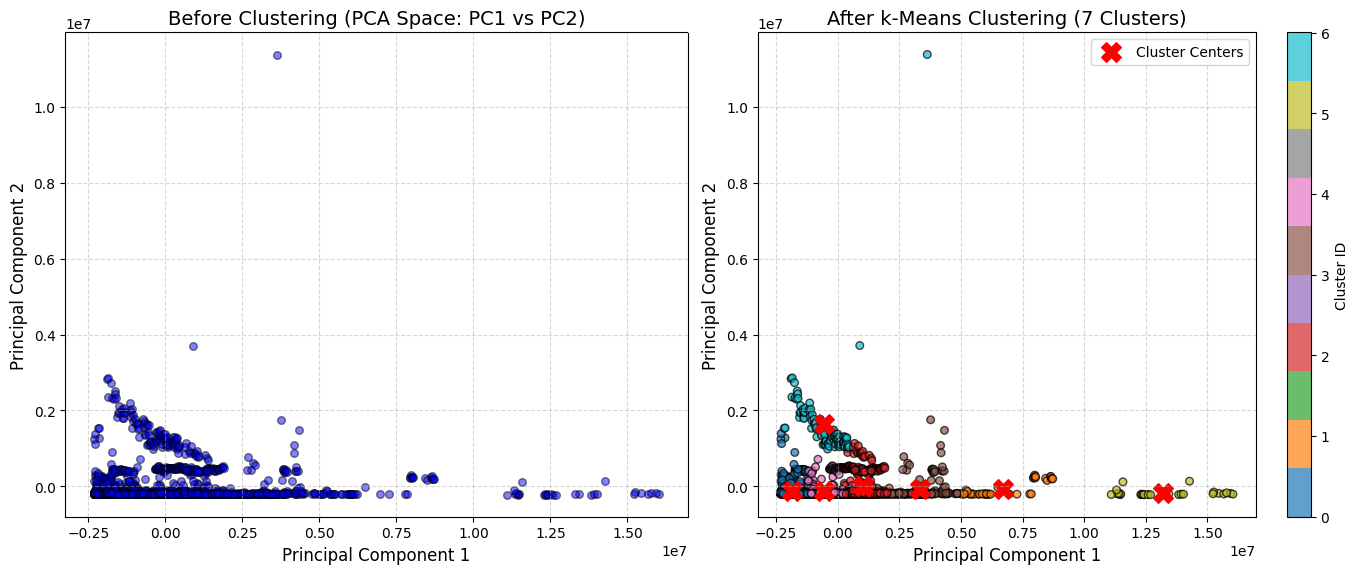

In [ ]:
# Plot data before and after clustering using the first 2 principal components
plt.figure(figsize=(14, 6))

# Plot 1: Before Clustering (Data projected on PC1 and PC2)
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', alpha=0.5, edgecolors='k', s=30)
plt.title("Before Clustering (PCA Space: PC1 vs PC2)", fontsize=14)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Plot 2: After k-Means Clustering
plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.7, edgecolors='k', s=30)

# Mark cluster centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, label='Cluster Centers')
plt.title("After k-Means Clustering (7 Clusters)", fontsize=14)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.legend()
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()